# ASSIGNMENT 2: PREDICTIVE ANALYTICS 

### Preeti Nair (20352859)  
### Yamit Chinchilla (20226488)  
### Aniruth Vaatikuti (20298656)  
### Ila Lagang (22022642)


——————————————————————
By including this statement, we the authors of this work, verify that:
    
- I hold a copy of this assignment that we can produce if the original is lost or damaged.

- I hereby certify that no part of this assignment/product has been copied from any other student’s work or from any other source except where due acknowledgement is made in the assignment.

- No part of this assignment/product has been written/produced for us by another person except where such collaboration has been authorised by the subject lecturer/tutor concerned.
- I am aware that this work may be reproduced and submitted to plagiarism detection software programs for the purpose of detecting possible plagiarism (which may retain a copy on its database for future plagiarism checking).
- I hereby certify that we have read and understand what the School of Computer, Data and Mathematical Sciences defines as minor and substantial breaches of misconduct as outlined in the learning guide for this unit.
——————————————————————

In [14]:
# Common imports
import numpy as np
import os
import pandas as pd
import seaborn as sns
# to make this notebook's output stable across runs
np.random.seed(47)
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
from tabulate import tabulate
from mlxtend.plotting import plot_decision_regions
# Models
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.decomposition import PCA
# Pre-processing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# Model performance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
#Neural network 
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from keras.utils.np_utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn import datasets,metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

The first stage of any project is understanding and pre-processing the data so that it is fit for analysis. Below, we load the dataset and describe it. The dataset comprises information collected from all the NSW public schools such as location, school type, enrolments, proportion of students with indigineous background, etc. 

In [15]:
import pandas as pd
## importing the NSW public school master dataset
school = pd.read_csv("master_dataset.csv")


In [16]:
school.head()

,School_code,AgeID,School_name,Street,Town_suburb,Postcode,Phone,School_Email,Website,Fax,...,FACS_district,Local_health_district,AECG_region,ASGS_remoteness,Latitude,Longitude,Assets unit,SA4,Healthy canteen,Date_extracted
0,1138,49127.0,Barnsley Public School,Cliffbrook St,Barnsley,2278,4953 2976,barnsley-p.school@det.nsw.edu.au,https://barnsley-p.schools.nsw.gov.au,4953 3094,...,Hunter New England & Central Coast,Hunter New England,Hunter,Major Cities of Australia,-32.933094,151.594552,Hunter/Central Coast,Newcastle and Lake Macquarie,N,2022-10-14
1,1139,50460.0,Barooga Public School,Hughes St,Barooga,3644,03 5873 4242,barooga-p.school@det.nsw.edu.au,https://barooga-p.schools.nsw.gov.au,03 5873 4700,...,"Murrumbidgee, Far West & Western NSW",Murrumbidgee,Riverina 2,Inner Regional Australia,-35.912963,145.695985,Southern NSW,Murray,N,2022-10-14
2,1140,49371.0,Barraba Central School,BARRABA CENTRAL PRIMARY SCHOOL 29 GOTHA STREET,BARRABA,2347,6782 1104,barraba-c.school@det.nsw.edu.au,https://barraba-c.schools.nsw.gov.au,6782 1231,...,Hunter New England & Central Coast,Hunter New England,North Western 2,Outer Regional Australia,-30.382390,150.599478,North Western NSW,New England and North West,N,2022-10-14
3,1143,49523.0,Barrington Public School,1 Kenmore St,Barrington,2422,6558 4258,barrington-p.school@det.nsw.edu.au,https://barrington-p.schools.nsw.gov.au,6558 4216,...,Hunter New England & Central Coast,Hunter New England,Manning,Outer Regional Australia,-31.971159,151.911058,North Coast,Mid North Coast,N,2022-10-14
4,1146,49683.0,Baryulgil Public School,7135 Clarence Way,Baryulgil,2460,6647 2124,baryulgil-p.school@det.nsw.edu.au,https://baryulgil-p.schools.nsw.gov.au,6647 2151,...,Mid North Coast & Northern NSW,Northern NSW,Upper North Coast,Outer Regional Australia,-29.223500,152.605615,North Coast,Coffs Harbour - Grafton,N,2022-10-14


The objective of our study is to understand the factors which have an impact on the ICSEA value (Index of Community Socio-Educational Advantage). A high ICSEA value basically means that there is a higher educational advantage for the students.

In [17]:
school.describe()

,School_code,AgeID,Postcode,latest_year_enrolment_FTE,ICSEA_value,Support_classes,Latitude,Longitude
count,2211.000000,2209.000000,2211.000000,2168.000000,2161.000000,0.0,2211.000000,2211.000000
mean,4277.917232,50346.623812,2416.581637,369.852583,979.635354,NaN,-33.174738,150.622069
std,2348.878843,7318.814241,247.485935,325.676577,94.497302,NaN,1.736098,1.845393
min,1001.000000,6354.000000,2000.000000,2.000000,100.000000,NaN,-37.084209,141.439970
25%,2399.000000,48152.000000,2204.000000,98.000000,924.000000,NaN,-33.975495,150.592943
50%,3948.000000,49671.000000,2420.000000,297.000000,975.000000,NaN,-33.765473,150.994974
75%,5553.500000,50788.000000,2587.000000,545.625000,1039.000000,NaN,-32.806442,151.315380
max,8917.000000,87909.000000,4383.000000,2006.500000,1245.000000,NaN,-28.169510,159.069032


After reading up on how ICSEA is calculated, the four factors affecting it are - Parents occupation,
Geographical Location, Parents education and Proportion of indigenous students.

After the first exploration with the Dataset, we have concluded that there exist some information 
irrelevant to our object of study such as: websites, phone numbers, fax directories and political affiliation. 

The data is identified at a unique school code level and consists of 2211 schools. We have 
narrowed the Dataset to 26 original variables and 2211 observations. The variables dropped consists 
of information relating to: 
1. Phone number, website, fax and school name which are specific to a particular school. We already h
have school code to identify the observations at a unique school level. Postcode has been dropped since 
town suburb variable has location data at a more granular level about the location of the school.
2. Electorate information consisting of address and phone number. Electorate area information helps 
us to identify the district level location of the school. We already have the town suburb, local 
health district, Assets Unit, ASGS remoteness and FACS district capturing information on location. 
The objective of the study is not to understand the political affiliation, hence these variables have 
not been considered.Therefore at this stage, we have only removed the variables which are NOT 
significant to our analysis or variables which hold the same information in different variables. 
3. Variable support class where the entire column is blank

In [18]:
school_final= school.drop(['School_name','Phone','Street','School_Email','Website','Fax','Date_1st_teacher',
                           'LGA','electorate_from_2023','electorate_2015_2022', 'Fed_electorate',
                           'Operational_directorate','Principal_network','Operational_directorate_office',
                           'Operational_directorate_office_phone','Operational_directorate_office_address'
                            , 'Date_extracted','Postcode','Support_classes'], axis=1)


In [19]:
school_final.shape

(2211, 26)

In [20]:
school_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2211 entries, 0 to 2210
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   School_code                2211 non-null   int64  
 1   AgeID                      2209 non-null   float64
 2   Town_suburb                2210 non-null   object 
 3   latest_year_enrolment_FTE  2168 non-null   float64
 4   Indigenous_pct             2168 non-null   object 
 5   LBOTE_pct                  2156 non-null   object 
 6   ICSEA_value                2161 non-null   float64
 7   Level_of_schooling         2211 non-null   object 
 8   Selective_school           2211 non-null   object 
 9   Opportunity_class          2211 non-null   object 
 10  School_specialty_type      2211 non-null   object 
 11  School_subtype             2211 non-null   object 
 12  Preschool_ind              2211 non-null   object 
 13  Distance_education         2211 non-null   objec

From the above we can see that we have null values present for few of the variables.

In order to ease the manipulation of this dataset, we have changed the name of 1 column and 
tranformed the variables Indigenous pct and Language Background other than english that came 
as object in the original dataset to numeric.


In [21]:
school_final = school_final.rename(columns = {'Assets unit':'Assets_unit'})
#The variables have suppressed data indicated as "sp". Converting the data to numeric 
#using coerce will replace those values with a blank and allow us to do missing value treatment.
school_final['Indigenous_pct'] = pd.to_numeric(school_final['Indigenous_pct'],errors='coerce')
school_final['LBOTE_pct'] = pd.to_numeric(school_final['LBOTE_pct'],errors='coerce')
school_final.columns

Index(['School_code', 'AgeID', 'Town_suburb', 'latest_year_enrolment_FTE',
       'Indigenous_pct', 'LBOTE_pct', 'ICSEA_value', 'Level_of_schooling',
       'Selective_school', 'Opportunity_class', 'School_specialty_type',
       'School_subtype', 'Preschool_ind', 'Distance_education',
       'Intensive_english_centre', 'School_gender', 'Late_opening_school',
       'FACS_district', 'Local_health_district', 'AECG_region',
       'ASGS_remoteness', 'Latitude', 'Longitude', 'Assets_unit', 'SA4',
       'Healthy canteen'],
      dtype='object')

For continuous variables like Indigenous pct and LBOTE pct, we created an indicator where the values are missing by assigning 1 or 0 if it is NA or null. 

In [22]:
for var in ['Indigenous_pct', 'LBOTE_pct']:
    school_final[var + '_NA'] = np.where(school_final[var].isnull(), 1, 0)

To conclude this first  part of the pre processing stage, the authors have decided to replace the missing values in each variable with the median, using the Level of schooling as grouping factor. We have picked the median, as we will show later  in the graphs later the density of our Target variable is skewed, and if we introduce the mean this will push our values and furthermore affect the predictions whereas median is not impacted due to extreme values.

In [23]:

school_final['LBOTE_pct'] = school_final['LBOTE_pct'].fillna(school_final.groupby
                                                             ('Level_of_schooling')['LBOTE_pct'].transform('median'))
school_final['Indigenous_pct'] = school_final['Indigenous_pct'].fillna(school_final.groupby('Level_of_schooling')                                                                      ['Indigenous_pct'].transform('mean'))
school_final['latest_year_enrolment_FTE'] = school_final['latest_year_enrolment_FTE'].fillna(school_final.groupby
                                                 ('Level_of_schooling')['latest_year_enrolment_FTE'].transform('median'))
school_final['ICSEA_value'] = school_final['ICSEA_value'].fillna(school_final.groupby
                                                             ('Level_of_schooling')['ICSEA_value'].transform('median'))

In [24]:
school_final.head()

,School_code,AgeID,Town_suburb,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,ICSEA_value,Level_of_schooling,Selective_school,Opportunity_class,...,Local_health_district,AECG_region,ASGS_remoteness,Latitude,Longitude,Assets_unit,SA4,Healthy canteen,Indigenous_pct_NA,LBOTE_pct_NA
0,1138,49127.0,Barnsley,309.0,14.000000,2.0,954.0,Primary School,Not Selective,N,...,Hunter New England,Hunter,Major Cities of Australia,-32.933094,151.594552,Hunter/Central Coast,Newcastle and Lake Macquarie,N,0,0
1,1139,50460.0,Barooga,94.0,14.264935,15.0,985.0,Primary School,Not Selective,N,...,Murrumbidgee,Riverina 2,Inner Regional Australia,-35.912963,145.695985,Southern NSW,Murray,N,1,1
2,1140,49371.0,BARRABA,162.0,27.000000,5.0,891.0,Central/Community School,Not Selective,N,...,Hunter New England,North Western 2,Outer Regional Australia,-30.382390,150.599478,North Western NSW,New England and North West,N,0,1
3,1143,49523.0,Barrington,51.0,16.000000,0.0,985.0,Primary School,Not Selective,N,...,Hunter New England,Manning,Outer Regional Australia,-31.971159,151.911058,North Coast,Mid North Coast,N,0,0
4,1146,49683.0,Baryulgil,11.0,100.000000,15.0,653.0,Primary School,Not Selective,N,...,Northern NSW,Upper North Coast,Outer Regional Australia,-29.223500,152.605615,North Coast,Coffs Harbour - Grafton,N,0,1


In [25]:
school_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2211 entries, 0 to 2210
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   School_code                2211 non-null   int64  
 1   AgeID                      2209 non-null   float64
 2   Town_suburb                2210 non-null   object 
 3   latest_year_enrolment_FTE  2187 non-null   float64
 4   Indigenous_pct             2187 non-null   float64
 5   LBOTE_pct                  2187 non-null   float64
 6   ICSEA_value                2187 non-null   float64
 7   Level_of_schooling         2211 non-null   object 
 8   Selective_school           2211 non-null   object 
 9   Opportunity_class          2211 non-null   object 
 10  School_specialty_type      2211 non-null   object 
 11  School_subtype             2211 non-null   object 
 12  Preschool_ind              2211 non-null   object 
 13  Distance_education         2211 non-null   objec

We can see even after missing value imputation at a school type level, we still have missing values.
For all Environmental schools, there is no information populated for latest_year_enrolment_FTE, Indigenous_pct, LBOTE_pct and ICSEA_value. Hence, we remove these observations from our data. This would result in removal of 1%(24 observation out of 2211) of records from the overall data.

In [26]:
school_final = school_final[~school_final['ICSEA_value'].isnull()] 
school_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2187 entries, 0 to 2210
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   School_code                2187 non-null   int64  
 1   AgeID                      2186 non-null   float64
 2   Town_suburb                2186 non-null   object 
 3   latest_year_enrolment_FTE  2187 non-null   float64
 4   Indigenous_pct             2187 non-null   float64
 5   LBOTE_pct                  2187 non-null   float64
 6   ICSEA_value                2187 non-null   float64
 7   Level_of_schooling         2187 non-null   object 
 8   Selective_school           2187 non-null   object 
 9   Opportunity_class          2187 non-null   object 
 10  School_specialty_type      2187 non-null   object 
 11  School_subtype             2187 non-null   object 
 12  Preschool_ind              2187 non-null   object 
 13  Distance_education         2187 non-null   objec

In [27]:
school_final= school_final.drop(["Indigenous_pct_NA","LBOTE_pct_NA",'Latitude',"Longitude",                              
                                 "AgeID",'School_code'], 
                                axis = 1)

The problem at hand is a classification problem, where the authors are predicting if the ICSEA value falls in the low, medium or high bracket. The classification has been based on information sourced from the **acara** (Australian Curriculum, Assessment and Reporting authority)
https://docs.acara.edu.au/resources/About_icsea_2014.pdf

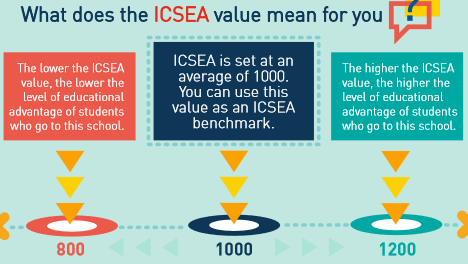

In [28]:
school_final.loc[(school_final.ICSEA_value <= 799) , 'final_ICSEA'] = 'Low'
school_final.loc[(school_final.ICSEA_value >= 800) & (school_final.ICSEA_value <= 1000), 'final_ICSEA'] = 'Medium'
school_final.loc[(school_final.ICSEA_value >= 1001) , 'final_ICSEA'] = 'High'

In [29]:
school_final.columns

Index(['Town_suburb', 'latest_year_enrolment_FTE', 'Indigenous_pct',
       'LBOTE_pct', 'ICSEA_value', 'Level_of_schooling', 'Selective_school',
       'Opportunity_class', 'School_specialty_type', 'School_subtype',
       'Preschool_ind', 'Distance_education', 'Intensive_english_centre',
       'School_gender', 'Late_opening_school', 'FACS_district',
       'Local_health_district', 'AECG_region', 'ASGS_remoteness',
       'Assets_unit', 'SA4', 'Healthy canteen', 'final_ICSEA'],
      dtype='object')

# Visualization of the data

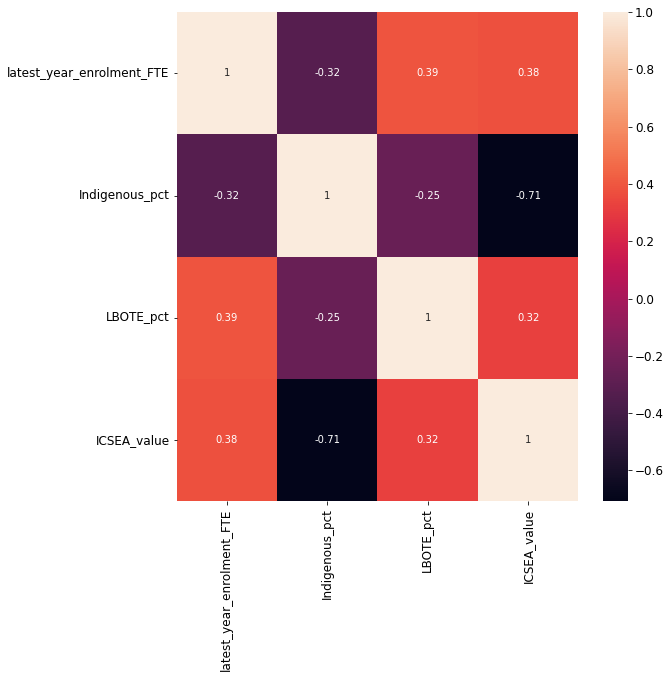

In [30]:
plt.figure(figsize=(9, 9))
correlation = school_final.corr()
heatmap = sns.heatmap(correlation, annot=True)
plt.show()

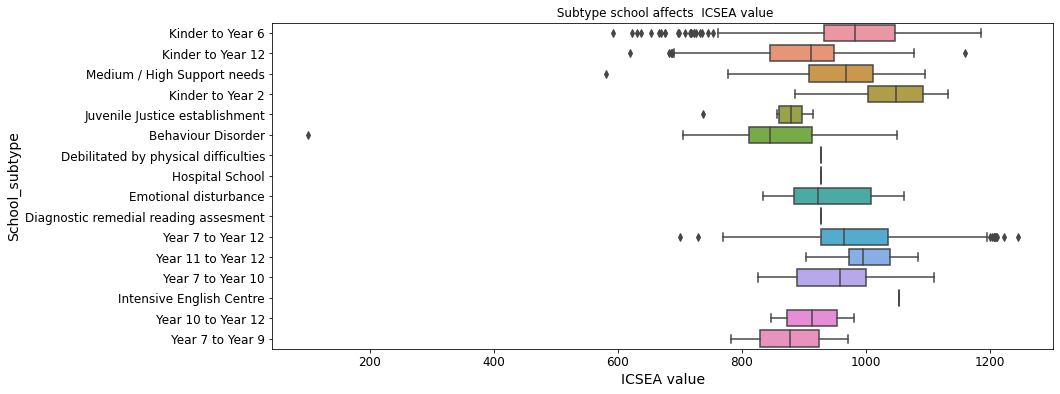

In [31]:
plt.figure(figsize = (14, 6))
sns.boxplot("ICSEA_value", 'School_subtype', data = school_final)
plt.title(" Subtype school affects  ICSEA value")
plt.xlabel('ICSEA value')
plt.show()

Text(0.5, 1.0, 'School Distribution')

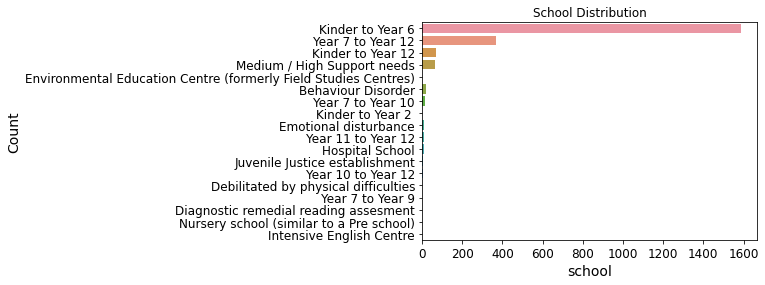

In [32]:
f, ax = plt.subplots()
figure = sns.countplot(y = 'School_subtype', data=school_final, order=['Kinder to Year 6','Year 7 to Year 12','Kinder to Year 12', 'Medium / High Support needs',
                                                               'Environmental Education Centre (formerly Field Studies Centres)','Behaviour Disorder',
                                                              'Year 7 to Year 10','Kinder to Year 2 ','Emotional disturbance',
                                                              'Year 11 to Year 12','Hospital School','Juvenile Justice establishment','Year 10 to Year 12',
                                                              'Debilitated by physical difficulties','Year 7 to Year 9','Diagnostic remedial reading assesment',
                                                              'Nursery school (similar to a Pre school)','Intensive English Centre'])
ax = ax.set(ylabel="Count", xlabel="school")
plt.title('School Distribution')

The graph below compares the variables Enrolment and ICSEA value. We can see that our ICSEA value have a range between the 600 and 1200 points, and a right skew distribution.

<AxesSubplot:xlabel='latest_year_enrolment_FTE', ylabel='Density'>

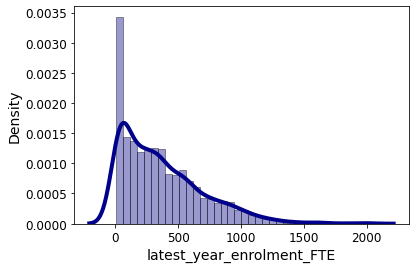

In [33]:
sns.distplot(school_final["latest_year_enrolment_FTE"], hist=True, kde=True, 
             bins=int(180/5), color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

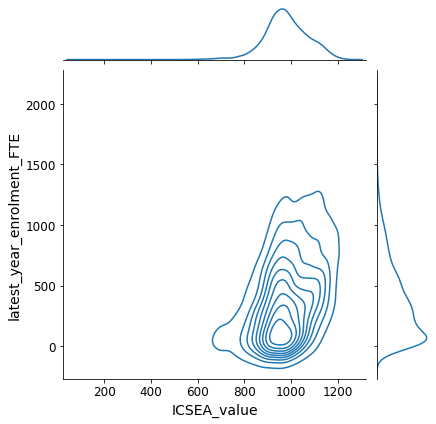

In [34]:
sns.jointplot(x = "ICSEA_value", y="latest_year_enrolment_FTE", data= school_final, kind = 'kde')


Text(0.5, 1.0, 'Selective School')

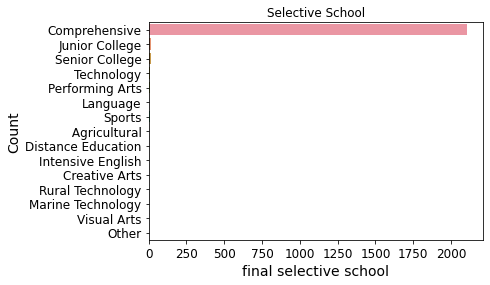

In [35]:
f, ax = plt.subplots()
figure = sns.countplot(y = 'School_specialty_type', data=school_final, order=['Comprehensive','Junior College',
                                                                             'Senior College', 'Technology', 'Performing Arts',
                                                                              'Language','Sports',' Agricultural', 'Distance Education',
                                                                              'Intensive English', 'Creative Arts', 'Rural Technology',
                                                                              'Marine Technology', 'Visual Arts', 'Other'
                                                                              ])
ax = ax.set(ylabel="Count", xlabel="final selective school")
plt.title('Selective School')

Text(0.5, 1.0, 'Gender School')

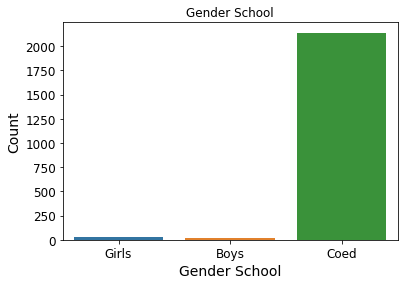

In [36]:
f, ax = plt.subplots()
figure = sns.countplot(x = 'School_gender', data=school_final, order=['Girls','Boys',"Coed"])
ax = ax.set(ylabel="Count", xlabel="Gender School")
plt.title('Gender School')

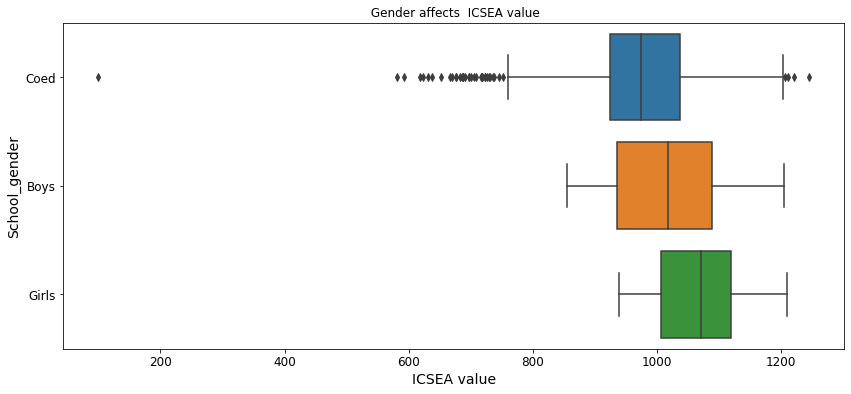

In [37]:
plt.figure(figsize = (14, 6))
sns.boxplot("ICSEA_value", 'School_gender', data = school_final)
plt.title(" Gender affects  ICSEA value")
plt.xlabel('ICSEA value')
plt.show()

In order to have an overview of the Urban schools and Rural schools, the authors have plotted the remotness of the schools and set 2 levels to compare the data, Urban city Sydney and Regional.


Text(0.5, 1.0, 'NSW  School Areas')

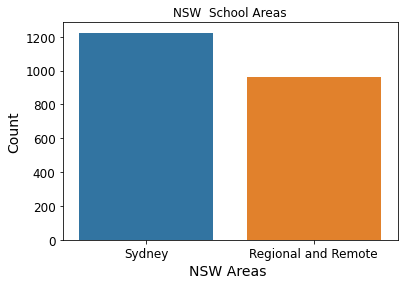

In [38]:
school_final.loc[(school_final.ASGS_remoteness =="Major Cities of Australia") , 'final_Remotness'] = 'Sydney'
school_final.loc[(school_final.ASGS_remoteness !="Major Cities of Australia") , 'final_Remotness'] = 'Regional and Remote'


f, ax = plt.subplots()
figure = sns.countplot(x = 'final_Remotness', data=school_final, order=['Sydney','Regional and Remote'])
ax = ax.set(ylabel="Count", xlabel="NSW Areas ")
plt.title('NSW  School Areas')

The violin graph below allow us to visualise the remoteness of each school by level of schooling. It shows the different schools (Primary school, Secondary school, etc) currently existing in Sydney and Regional areas compared against the performance index ICSEA. 

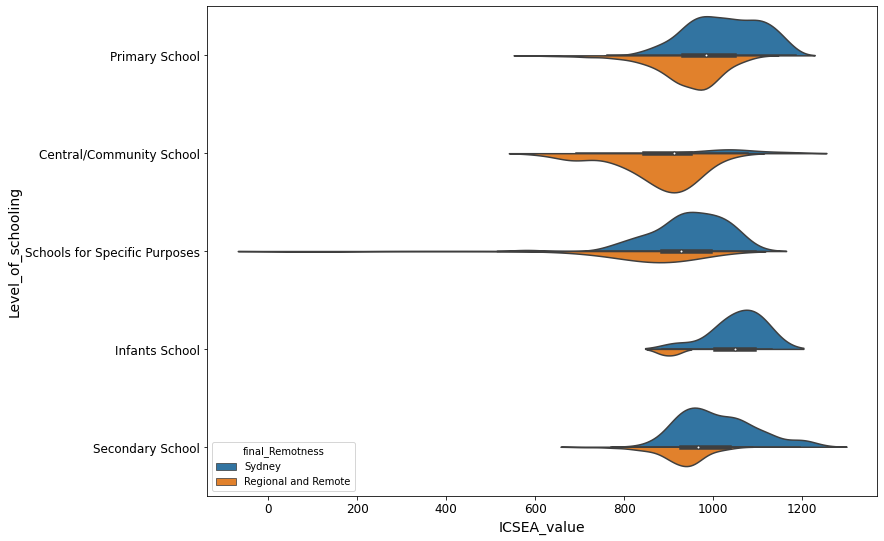

In [39]:

fig, ax = plt.subplots(figsize = (12,9))
ax = sns.violinplot(school_final["ICSEA_value"],
                    school_final['Level_of_schooling'],hue='final_Remotness', 
                    data= school_final, scale="count", split=True, ax=ax)

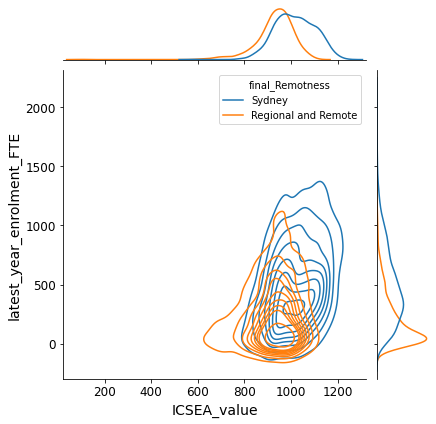

In [40]:
sns.jointplot(x = "ICSEA_value", y="latest_year_enrolment_FTE", data= school_final, kind = 'kde', hue = 'final_Remotness')


The healthy canteen is a program supplied by the governement in some schools with everyday meals and snacks. Below is an approach of how this variable will be related with our target variable.


Text(0.5, 1.0, 'Healthy Canteen')

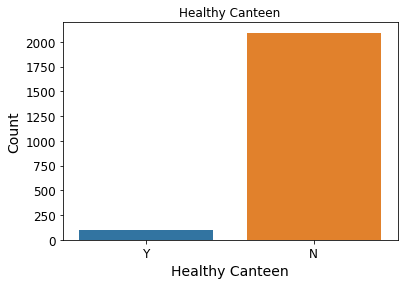

In [41]:
f, ax = plt.subplots()
figure = sns.countplot(x = 'Healthy canteen', data=school_final, order=['Y','N'])
ax = ax.set(ylabel="Count", xlabel="Healthy Canteen")
plt.title('Healthy Canteen')

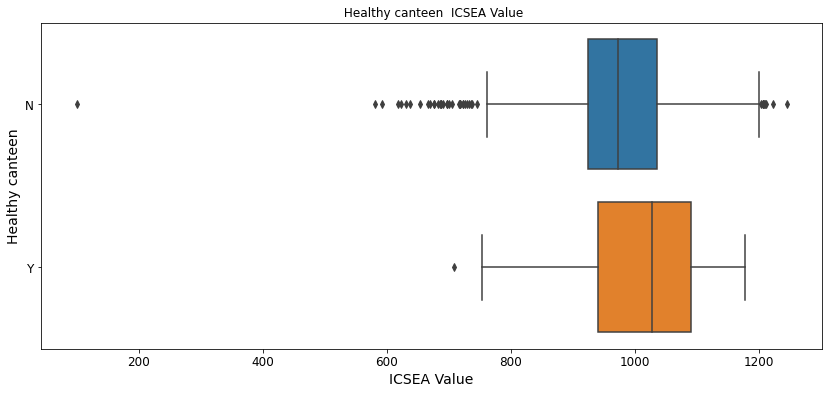

In [42]:
plt.figure(figsize = (14, 6))
sns.boxplot("ICSEA_value", 'Healthy canteen',data = school_final)
plt.title(" Healthy canteen  ICSEA Value")
plt.xlabel('ICSEA Value')
plt.show()

Below we want to see the impact of having community and family services in the performance of the children.

In [43]:
school_final['FACS_district'].value_counts()

Hunter New England & Central Coast                451
South Eastern Sydney, Northern Sydney & Sydney    417
Murrumbidgee, Far West & Western NSW              354
Western Sydney & Nepean Blue Mountains            301
South Western Sydney                              244
Mid North Coast & Northern NSW                    219
Illawarra Shoalhaven & Southern NSW               201
Name: FACS_district, dtype: int64

Text(0.5, 1.0, 'Family and Community services district')

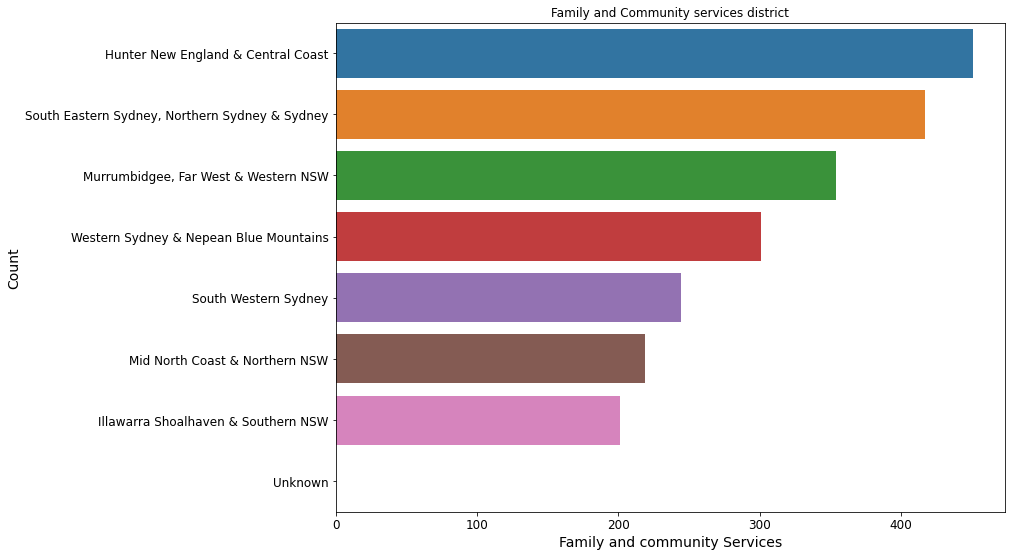

In [44]:
fig, ax = plt.subplots(figsize = (12,9))
figure = sns.countplot(y = 'FACS_district', data=school_final, order=['Hunter New England & Central Coast','South Eastern Sydney, Northern Sydney & Sydney',
                                                                     'Murrumbidgee, Far West & Western NSW','Western Sydney & Nepean Blue Mountains','South Western Sydney',
                                                                     'Mid North Coast & Northern NSW','Illawarra Shoalhaven & Southern NSW','Unknown'])
ax = ax.set(ylabel="Count", xlabel="Family and community Services")
plt.title('Family and Community services district')


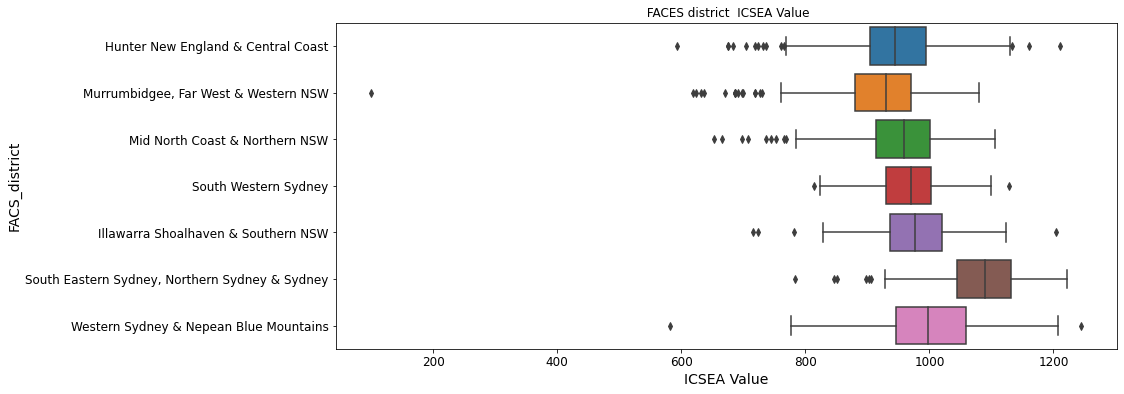

In [45]:
plt.figure(figsize = (14, 6))
sns.boxplot("ICSEA_value", 'FACS_district',data = school_final)
plt.title(" FACES district  ICSEA Value")
plt.xlabel('ICSEA Value')
plt.show()

From the graphs above we can see that there is negative correlation between the number of family centers and the ICSEA value, in places like Western Sydney and Far West or Hunter New England the number of FACS is larger than other places but this fact no necessarily helps the kids to get a better performance at school.

Below is shown the percentage of aboriginal people enrolled at schools and the language background differnt than english, clearly we can see that the numberof schools where the presence of aboriginal people is less than 20% is over the half of the observations. Also only a small proportion of the schools have a program that provide another language options for the kids with different backgrounds.


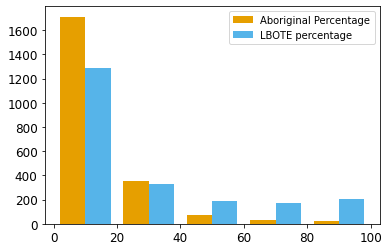

In [46]:
x1 = school_final['Indigenous_pct']
x2 = school_final['LBOTE_pct']

colors = ['#E69F00', '#56B4E9']
names = ['Aboriginal Percentage', 'LBOTE percentage']

plt.hist([x1, x2], bins = 5 , color = colors, label=names)
plt.legend()


# BIVARIATE ANALYSIS

In [47]:
school_final['final_ICSEA'].value_counts()

Medium    1282
High       838
Low         67
Name: final_ICSEA, dtype: int64

Text(0, 0.5, 'Number of Schools')

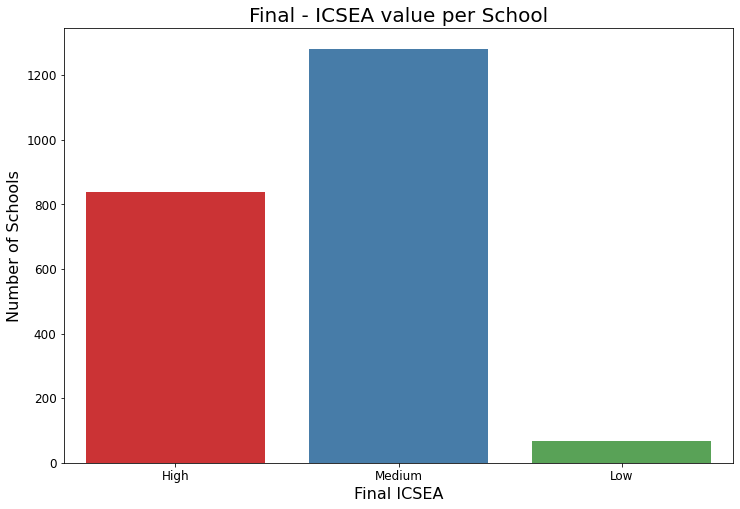

In [48]:
# Final Grade Countplot
plt.figure(figsize=(12,8))
sns.countplot(school_final.final_ICSEA, order=["High","Medium","Low"], palette='Set1')
plt.title('Final - ICSEA value per School' ,fontsize=20)
plt.xlabel('Final ICSEA', fontsize=16)
plt.ylabel('Number of Schools', fontsize=16)

# Dummy Variables

To have a detailed information that can predict our classes accurately, the authors have decided to remove the grouping variable used to plot the NSW Schools and use the original Value. 

In [49]:
school_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2187 entries, 0 to 2210
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Town_suburb                2186 non-null   object 
 1   latest_year_enrolment_FTE  2187 non-null   float64
 2   Indigenous_pct             2187 non-null   float64
 3   LBOTE_pct                  2187 non-null   float64
 4   ICSEA_value                2187 non-null   float64
 5   Level_of_schooling         2187 non-null   object 
 6   Selective_school           2187 non-null   object 
 7   Opportunity_class          2187 non-null   object 
 8   School_specialty_type      2187 non-null   object 
 9   School_subtype             2187 non-null   object 
 10  Preschool_ind              2187 non-null   object 
 11  Distance_education         2187 non-null   object 
 12  Intensive_english_centre   2187 non-null   object 
 13  School_gender              2187 non-null   objec

To overcome the Dummy variable Trap, we drop one of the columns created when the categorical variables were converted to dummy variables

In [50]:
# columns not to transform
not_cols =[
       'latest_year_enrolment_FTE', 'Indigenous_pct', 'LBOTE_pct',
       'ICSEA_value', 'Latitude', 'Longitude','final_ICSEA'
        ] 

# get dummies
df_dummies = pd.get_dummies(data=school_final, columns=[col for col in school_final.columns if col not in not_cols],drop_first=True)

In [51]:
df_dummies.columns

Index(['latest_year_enrolment_FTE', 'Indigenous_pct', 'LBOTE_pct',
       'ICSEA_value', 'final_ICSEA', 'Town_suburb_ADELONG',
       'Town_suburb_ALLAMBIE HEIGHTS', 'Town_suburb_APPIN',
       'Town_suburb_ARCADIA', 'Town_suburb_ARGENTON',
       ...
       'SA4_Sydney - North Sydney and Hornsby',
       'SA4_Sydney - Northern Beaches', 'SA4_Sydney - Outer South West',
       'SA4_Sydney - Outer West and Blue Mountains', 'SA4_Sydney - Parramatta',
       'SA4_Sydney - Ryde', 'SA4_Sydney - South West',
       'SA4_Sydney - Sutherland', 'Healthy canteen_Y',
       'final_Remotness_Sydney'],
      dtype='object', length=1723)

In [52]:
#we consider the new ICSEA classes created
y=df_dummies['final_ICSEA']
X=df_dummies.drop(['final_ICSEA','ICSEA_value'],axis=1)

The dataset has dummy variables. It is important to ensure the data used for modelling is scaled. Dummy variables take the value of either 0 or 1 and need not be standardised, we just need to standardise the numerical ones, but using MaxMin scaler we can pass both numerical and dummy variables because this scaler doesn't change the values of dummy variables, hence we apply zi=xi−min(x)max(x)−min(x). This MinMAxScaler will normalize our data, and allow us to assume that our Data is distributed Normally, which was not an assumption from the beginning.
Also, the data does not have outliers, so even though it is dependent on the minimum and maximum value, chance of bias does not arise.

In [53]:
#Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100,test_size=0.2)
#Minmaxscalaer ensures only the variables which are not scaled are being normalised
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Part 1a: Using the linear SVM to fit the model

In [54]:
clf1= LinearSVC(C=1, loss="hinge", max_iter=1e4, random_state = 42) # Linear Kernel
#Train the model using the training sets
clf1.fit(X_train, y_train)

LinearSVC(C=1, loss='hinge', max_iter=10000.0, random_state=42)

In [55]:
from sklearn import metrics
y_pred = clf1.predict(X_test)
Accuracy =metrics.accuracy_score(y_test, y_pred)*100
Accuracy

84.47488584474885

In [56]:
print(classification_report(y_test,y_pred))#Output
print(confusion_matrix(y_pred,y_test))

              precision    recall  f1-score   support

        High       0.92      0.72      0.81       170
         Low       0.71      0.38      0.50        13
      Medium       0.81      0.95      0.88       255

    accuracy                           0.84       438
   macro avg       0.82      0.69      0.73       438
weighted avg       0.85      0.84      0.84       438

[[123   0  11]
 [  0   5   2]
 [ 47   8 242]]


As a first run, using all variables we can see that our model has 84.5%

# Part 1b: Using non-linear SVM kernel 'rbf'

In [57]:
# Start with just some default parameters
clf2 = SVC(kernel="rbf", gamma='scale', C=100, max_iter=1e4, random_state=42)
clf2.fit(X_train,y_train)

SVC(C=100, max_iter=10000.0, random_state=42)

In [58]:
y_pred = clf2.predict(X_test)
Accuracy =metrics.accuracy_score(y_test, y_pred)*100
Accuracy

83.78995433789954

Using the radial basis function SVM with all the variables, we get an accuracy of 83.8%

# Part 1c: Evaluating the best fit kernel

Using GridSearchCV we are tuning the hyperparamters. C is the penalty term which denotes the misclassification term, i.e., how much of the error is permissible. Higher the value of C, the chances of classifying data points correctly are higher. It helps us to control the trade-off between decision boundary and error term. Gamma indicates the how the points will have an influence on the decision boundary. Higer the value of gamma, closer points will have a higher influence. Also we are using a Cross validation value of 5, it means, the dataset will be split into 5 folds and run the train and test groups in order to get the optimal C and Gamma.


In [59]:
param_grid = {'C': [0.01, 0.1, 0.5, 1, 10, 100], 
              'gamma': [1, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001], 
              'kernel': ['rbf', 'poly', 'linear']} 


grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv = 5 )
grid.fit(X_train, y_train)
#the optimum parameters
print(grid.best_estimator_)

SVC(C=1, gamma=1, kernel='linear')


We can now inspect the results of our search, sorted by their mean_test_score or Area under teh ROC curve:

In [62]:
results_df = pd.DataFrame(grid.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
1_1_linear,"{'C': 1, 'gamma': 1, 'kernel': 'linear'}",1,0.818179,0.005383
1_0.75_linear,"{'C': 1, 'gamma': 0.75, 'kernel': 'linear'}",1,0.818179,0.005383
1_0.5_linear,"{'C': 1, 'gamma': 0.5, 'kernel': 'linear'}",1,0.818179,0.005383
1_0.25_linear,"{'C': 1, 'gamma': 0.25, 'kernel': 'linear'}",1,0.818179,0.005383
1_0.1_linear,"{'C': 1, 'gamma': 0.1, 'kernel': 'linear'}",1,0.818179,0.005383
...,...,...,...,...
0.01_0.001_rbf,"{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}",107,0.587194,0.001890
0.01_0.01_poly,"{'C': 0.01, 'gamma': 0.01, 'kernel': 'poly'}",107,0.587194,0.001890
0.01_0.01_rbf,"{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}",107,0.587194,0.001890


We can see that the estimator using the 'linear' kernel performed best, compared to the'rbf' and 'poly. To evaluate the performance of two models we should statistically compare their AUC scores. There are 100 samples (AUC scores) for each model as we repreated 5 times a 5-fold cross-validation.

All models are evaluated on the same partitions, this will increase the correlation between the performance of the models. The scores of the models will co-vary since some data partitions may make it unusually simple or difficult for all models to distinguish between the classes.

Plotting this partition effect, the performance of all models in each fold:


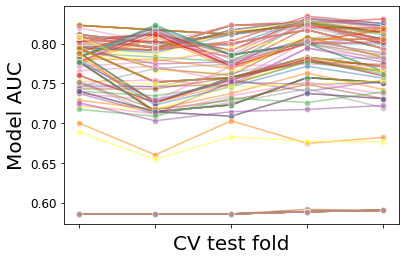

In [65]:
# create df of model scores ordered by performance
model_scores = results_df.filter(regex=r"split\d*_test_score")

# plot 30 examples of dependency between cv fold and AUC scores
fig, ax = plt.subplots()
sns.lineplot(
    data=model_scores.transpose().iloc[:30],
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

#plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
ax.set_xlabel("CV test fold", size=20, labelpad=10)
ax.set_ylabel("Model AUC", size=20)
ax.tick_params(bottom=True, labelbottom=False)
ax.get_legend().remove()
plt.show()

Using the optimal paramters, we see that using linear kernel gives us the best results with C=1 and gamma=1, with a score of 81%.

In [66]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))#Output
print('Accuracy of training: ', accuracy_score(y_test, grid_predictions) * 100)

[[132   0  38]
 [  0   7   6]
 [ 17   2 236]]
              precision    recall  f1-score   support

        High       0.89      0.78      0.83       170
         Low       0.78      0.54      0.64        13
      Medium       0.84      0.93      0.88       255

    accuracy                           0.86       438
   macro avg       0.84      0.75      0.78       438
weighted avg       0.86      0.86      0.85       438

Accuracy of training:  85.61643835616438


By using hyperparamter tuning method, we arrive at the optimal parameters resulting in higher accuracy results compared to just using linear or non-linear SVM.


There was a slight improvement in the accuracy after tuning the hyperparameters. The confusion matrix of the model shows that the  FP (False Positive), meaning that the probability to predict the  wrong  class, has decreased, i.e., the predictions are more precise. 


# Part2: Lasso Regression for variable selection

In order to select the significant variables, and reduce the dimension of our dataset, after running SVM using all the variables, we are using Lasso for variable selection. It can be used as a method of variable selection as this kind of regression optimizes the cost function by reducing the absolute values of the coefficients, using shrinkage. The coefficients will help us choose the variables which are useful to reduce this multidimensional dataset.


In [67]:
df_dummies.head()

,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,ICSEA_value,final_ICSEA,Town_suburb_ADELONG,Town_suburb_ALLAMBIE HEIGHTS,Town_suburb_APPIN,Town_suburb_ARCADIA,Town_suburb_ARGENTON,...,SA4_Sydney - North Sydney and Hornsby,SA4_Sydney - Northern Beaches,SA4_Sydney - Outer South West,SA4_Sydney - Outer West and Blue Mountains,SA4_Sydney - Parramatta,SA4_Sydney - Ryde,SA4_Sydney - South West,SA4_Sydney - Sutherland,Healthy canteen_Y,final_Remotness_Sydney
0,309.0,14.000000,2.0,954.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,94.0,14.264935,15.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162.0,27.000000,5.0,891.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,51.0,16.000000,0.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.0,100.000000,15.0,653.0,Low,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
# Lasso regression
df_dummies['ICSEA_fac'] = df_dummies['final_ICSEA'].map({
    "High": 0,
    "Medium": 1,
    "Low": 2
})
y=df_dummies['ICSEA_fac']
X=df_dummies.drop(['final_ICSEA','ICSEA_value','ICSEA_fac'],axis=1)


We first split the data and since our data contains dummy variables as well, it is important to ensure the data is scaled

We now want to determine the optimum value of alpha where the test error is minimum.


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=100)
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

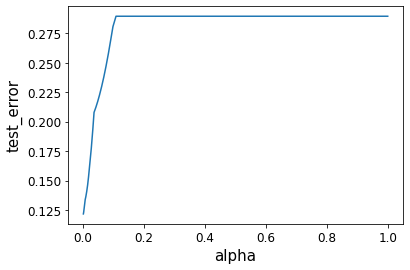

In [70]:
alphas = np.arange(1e-3, 1, 1e-3)
test_error = []
coefs = []
for alpha in alphas:
    lasso_reg = Lasso(alpha=alpha, random_state=42)
    lasso_reg.fit(X_train, y_train)
    coefs.append(lasso_reg.coef_)
    ypred = lasso_reg.predict(X_test)
    test_error.append(mean_squared_error(y_test, ypred))
plt.plot(alphas, test_error)
plt.xlabel('alpha',fontsize=15)
plt.ylabel('test_error',fontsize=15)
plt.show()

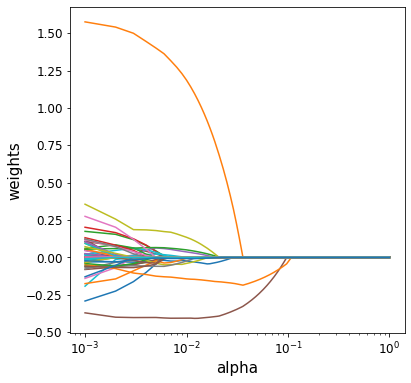

In [71]:
features = np.array(X.columns)
plt.figure(figsize = (6,6))
ax = plt.gca()
ax.plot(alphas, coefs,label=features)
ax.set_xscale("log")
plt.axis('tight')
plt.xlabel('alpha',fontsize=15)
plt.ylabel('weights',fontsize=15)
#plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
plt.show()

In [72]:
indA = np.argmin(test_error)
print('Minimum test error: ', test_error[indA], ' at alpha equals:',alphas[indA])

Minimum test error:  0.1216794651275189  at alpha equals: 0.001


Using the optimal alpha we now run the regression model to determine the coefficients which were not shrink zero:

In [73]:
lasso_reg = Lasso(alpha=0.001, random_state=42)
lasso_reg.fit(X_train, y_train)
ypred = lasso_reg.predict(X_test)
test_error.append(mean_squared_error(y_test, ypred))
lasso_reg.coef_

array([-0.2917054 ,  1.57572801, -0.05730671, ..., -0.03432258,
       -0.0096525 , -0.02224079])

We now only retain the coefficents which are not equal to 0 and are contributing to determine the target variable. Rest of the variables with coefficient 0 are discarded. 

In [74]:
coefficients=lasso_reg.coef_
importance = np.abs(coefficients)
features = X.columns
Ximp=np.array(features)[importance > 0]
Ximp

array(['latest_year_enrolment_FTE', 'Indigenous_pct', 'LBOTE_pct',
       'Town_suburb_Goulburn ', 'Town_suburb_Mullumbimby ',
       'Level_of_schooling_Infants School',
       'Level_of_schooling_Primary School',
       'Level_of_schooling_Secondary School',
       'Selective_school_Not Selective', 'Opportunity_class_Y',
       'School_specialty_type_Junior College',
       'School_subtype_Hospital School',
       'School_subtype_Medium / High Support needs', 'Preschool_ind_Y',
       'Intensive_english_centre_Y', 'School_gender_Coed',
       'FACS_district_South Eastern Sydney, Northern Sydney & Sydney',
       'FACS_district_South Western Sydney',
       'Local_health_district_Hunter New England',
       'Local_health_district_Murrumbidgee',
       'Local_health_district_Nepean Blue Mountains',
       'Local_health_district_South Western Sydney',
       'Local_health_district_Sydney',
       'Local_health_district_Western Sydney', 'AECG_region_Manning',
       'AECG_region_Metropol

In [75]:
Xnew=df_dummies[Ximp]
Xnew.head()

,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,Town_suburb_Goulburn,Town_suburb_Mullumbimby,Level_of_schooling_Infants School,Level_of_schooling_Primary School,Level_of_schooling_Secondary School,Selective_school_Not Selective,Opportunity_class_Y,...,SA4_Newcastle and Lake Macquarie,SA4_Richmond - Tweed,SA4_Sydney - Baulkham Hills and Hawkesbury,SA4_Sydney - Blacktown,SA4_Sydney - Inner West,SA4_Sydney - Outer West and Blue Mountains,SA4_Sydney - South West,SA4_Sydney - Sutherland,Healthy canteen_Y,final_Remotness_Sydney
0,309.0,14.000000,2.0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
1,94.0,14.264935,15.0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,162.0,27.000000,5.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,51.0,16.000000,0.0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,11.0,100.000000,15.0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
#we consider the new ICSEA classes created
y=df_dummies['final_ICSEA']
#Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(Xnew, y, random_state=100)
#Minmaxscalaer ensures only the variables which are not scaled are being normalised
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

We now use the variables selected using Lasso to run the SVM model. The optimal tuning parameters are chosen using cross validation.

In [77]:
param_grid = {'C': [0.01, 0.1, 0.5, 1, 10, 100], 
              'gamma': [1, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001], 
              'kernel': ['rbf', 'poly', 'linear']} 


grid2 = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv = 5)
grid2.fit(X_train, y_train)
print(grid2.best_estimator_)

SVC(C=100, gamma=1, kernel='linear')


We can now inspect the results of our search, sorted by their mean_test_score:

In [78]:
results2_df = pd.DataFrame(grid2.cv_results_)
results2_df = results2_df.sort_values(by=["rank_test_score"])
results2_df = results2_df.set_index(
    results2_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results2_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]


,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
100_0.001_linear,"{'C': 100, 'gamma': 0.001, 'kernel': 'linear'}",1,0.831707,0.02107
100_0.01_linear,"{'C': 100, 'gamma': 0.01, 'kernel': 'linear'}",1,0.831707,0.02107
100_0.1_linear,"{'C': 100, 'gamma': 0.1, 'kernel': 'linear'}",1,0.831707,0.02107
100_0.25_linear,"{'C': 100, 'gamma': 0.25, 'kernel': 'linear'}",1,0.831707,0.02107
100_1_linear,"{'C': 100, 'gamma': 1, 'kernel': 'linear'}",1,0.831707,0.02107
...,...,...,...,...
0.1_0.01_poly,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'poly'}",107,0.590854,0.00122
0.1_0.001_rbf,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}",107,0.590854,0.00122
0.1_0.001_poly,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'poly'}",107,0.590854,0.00122


Using the features picked by the lasso we can identify that the mean test score have slightly improved in each kernel. Below is shown the AUC score plot to display the performance of each model:


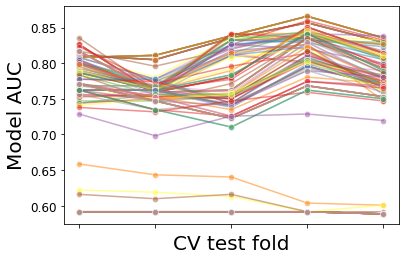

In [79]:
# create df of model scores ordered by performance
model_scores2 = results2_df.filter(regex=r"split\d*_test_score")

# plot 30 examples of dependency between cv fold and AUC scores
fig, ax = plt.subplots()
sns.lineplot(
    data=model_scores2.transpose().iloc[:30],
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

#plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
ax.set_xlabel("CV test fold", size=20, labelpad=10)
ax.set_ylabel("Model AUC", size=20)
ax.tick_params(bottom=True, labelbottom=False)
ax.get_legend().remove()
plt.show()

# print correlation of AUC scores across folds
#print(f"Correlation of models:\n {model_scores.transpose().corr()}")

Using the optimal parameters we now run the SVM Model


In [80]:
grid_predictions = grid2.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))#Output
print('Accuracy of training: ', accuracy_score(y_test, grid_predictions) * 100)

[[166   0  47]
 [  1  13   7]
 [ 32   2 279]]
              precision    recall  f1-score   support

        High       0.83      0.78      0.81       213
         Low       0.87      0.62      0.72        21
      Medium       0.84      0.89      0.86       313

    accuracy                           0.84       547
   macro avg       0.85      0.76      0.80       547
weighted avg       0.84      0.84      0.84       547

Accuracy of training:  83.72943327239489


From the table above we can recap that in every class we can see a higher number of positives samples correctly classified by our model. The accuracy of the model after selection of variables using Lasso is 83.7%. We do not see any improvement in the model after variable selection as the accuracy before and after discarding the variables are almost very close. The feature slection may help in terms of making this model more easy to interpret but not improve the performance, Lasso regression helped to speed up the construction of it. 

The precision using the above model with less features have better rates, the authors have observed that the precision for all of the classes are over 80%. It means that from a sample of 100 observation the model is correctly predicting over 80% of the times. 


In [64]:
Xnew.iloc[:,:2]

,latest_year_enrolment_FTE,Indigenous_pct
0,309.0,14.000000
1,94.0,14.264935
2,162.0,27.000000
3,51.0,16.000000
4,11.0,100.000000
...,...,...
2206,358.0,3.000000
2207,756.0,11.908587
2208,1141.4,17.000000
2209,565.0,6.000000


We now consider the 2 variables which has the highest absolute coefficient value (last year enrollment FTE and indigenous pct) from the lasso regression to plot the decision regions. This is just to get an idea of classification by the model with the optimum hyperparameters from above. We can see  how likely, each point in the feature space belongs to each of the class labels, as seen by the model.

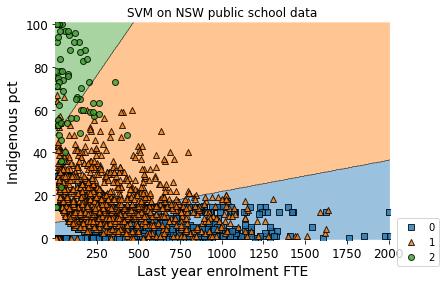

In [67]:
#we consider the ICSEA classes created
df_dummies['ICSEA_fac'] = df_dummies['final_ICSEA'].map({
    "High": 0,
    "Medium": 1,
    "Low": 2
})
X_p=Xnew.iloc[:,:2].to_numpy()
y_p=df_dummies['ICSEA_fac'].to_numpy()
# Create an Instance of SVM and Fit out the data.
svc = SVC(kernel ='linear', C = 100,gamma=1).fit(X_p, y_p)
##########################################################
# Plotting decision regions
plot_decision_regions(X_p, y_p, clf=svc,  legend=2)
##########################################################
# Adding axes annotations
plt.xlabel('Last year enrolment FTE')
plt.ylabel('Indigenous pct')
plt.title('SVM on NSW public school data')
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
plt.show()

# Part3: Variable selection using PCA

We have used another feature selection method - Principal Component Analysis to check if the accuracy of the model can be approved. Since the data has a large number of features, using PCA will help us to reduce the dimensionality of the data and simultaneously preserve all the important information.


In [68]:
#Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)
#Minmaxscalaer ensures only the variables which are not scaled are being normalised
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
X_test.shape

(547, 1721)

We are trying to ascertain the number of components which will help us determine 99% of the variance.

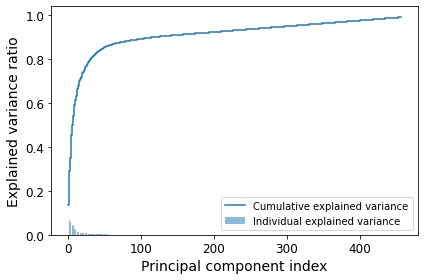

In [70]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [71]:
# the number of components that explain 95% of the variance
variance_cumsum = np.cumsum(pca.explained_variance_ratio_)
variance_cumsum.shape

(457,)

457 components explain 99% of the variance. Hence we now take 457 components and run the PCA


In [72]:
pca = PCA(n_components=457)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

In [73]:
clf_pca= LinearSVC(C=1, loss="hinge", max_iter=1e4, random_state = 42) # Linear Kernel
#Train the model using the training sets
clf_pca.fit(X_train_pca, y_train)
from sklearn import metrics
y_pred = clf_pca.predict(X_test_pca)
Accuracy =metrics.accuracy_score(y_test, y_pred)*100
Accuracy

46.80073126142596

In [74]:
param_grid = {'C': [0.01, 0.1, 0.5, 1, 10, 100], 
              'gamma': [1, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001], 
              'kernel': ['rbf', 'poly', 'linear']} 


grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0)
grid.fit(X_train_pca, y_train)
best_params = grid.best_params_
grid_predictions = grid.predict(X_test_pca)
print(f"Best params: {best_params}")
print(grid.best_estimator_)

Best params: {'C': 1, 'gamma': 1, 'kernel': 'linear'}
SVC(C=1, gamma=1, kernel='linear')


In [75]:
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))#Output
print('Accuracy of training: ', accuracy_score(y_test, grid_predictions) * 100)

[[ 77   3 133]
 [ 11   0  10]
 [134   5 174]]
              precision    recall  f1-score   support

        High       0.35      0.36      0.35       213
         Low       0.00      0.00      0.00        21
      Medium       0.55      0.56      0.55       313

    accuracy                           0.46       547
   macro avg       0.30      0.31      0.30       547
weighted avg       0.45      0.46      0.45       547

Accuracy of training:  45.88665447897623


Using PCA for variable selection method, does not improve the accuracy. In fact, the accuracy is poorer when we use PCA for variable selection due to the requirement of a large number of components to explain 99% of variation in the data.

## Comparison between SVM Models 

The Table below display  the accuracy of each  model by comparing the predictions for each SVM approach:

In [11]:
data = [["Linear SVM using all variables", 84.5 ], 
        ["SVM using kernel rbf using all variables", 83.7], 
        ["SVM by tuning parameter using all variables", 85.6], 
        ["Variable selection using Lasso and then SVM with selected variables", 83.7],
        ["Variable selection using PCA and then SVM with selected variables", 45.8]
       ]
  
#define header names
col_names = ["Method", "Accuracy %"]
  
#display table
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))


╒═════════════════════════════════════════════════════════════════════╤══════════════╕
│ Method                                                              │   Accuracy % │
╞═════════════════════════════════════════════════════════════════════╪══════════════╡
│ Linear SVM using all variables                                      │         84.5 │
├─────────────────────────────────────────────────────────────────────┼──────────────┤
│ SVM using kernel rbf using all variables                            │         83.7 │
├─────────────────────────────────────────────────────────────────────┼──────────────┤
│ SVM by tuning parameter using all variables                         │         85.6 │
├─────────────────────────────────────────────────────────────────────┼──────────────┤
│ Variable selection using Lasso and then SVM with selected variables │         83.7 │
├─────────────────────────────────────────────────────────────────────┼──────────────┤
│ Variable selection using PCA and then SVM

The accuracy of the SVM model using all variables with linear kernel after tuning the hyperparameters give us the highest accuracy. The most optimum kernel after tuning is linear with C=1 and gamma =1.
The non-linear kernel maps the data into a higher dimensional feature space but here in this dataset we already have a large number of features. Hence, the linear kernel gives us higher accuracy of 85.6%.


# KNN

In [79]:
# columns not to transform
not_cols =[
       'latest_year_enrolment_FTE', 'Indigenous_pct', 'LBOTE_pct',
       'ICSEA_value', 'Latitude', 'Longitude','final_ICSEA'
        ] 

# get dummies
df_dummies = pd.get_dummies(data=school_final, columns=[col for col in school_final.columns if col not in not_cols],drop_first=True)

In [80]:
df_dummies.head()

,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,ICSEA_value,final_ICSEA,Town_suburb_ADELONG,Town_suburb_ALLAMBIE HEIGHTS,Town_suburb_APPIN,Town_suburb_ARCADIA,Town_suburb_ARGENTON,...,SA4_Sydney - North Sydney and Hornsby,SA4_Sydney - Northern Beaches,SA4_Sydney - Outer South West,SA4_Sydney - Outer West and Blue Mountains,SA4_Sydney - Parramatta,SA4_Sydney - Ryde,SA4_Sydney - South West,SA4_Sydney - Sutherland,Healthy canteen_Y,final_Remotness_Sydney
0,309.0,14.000000,2.0,954.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,94.0,14.264935,15.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162.0,27.000000,5.0,891.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,51.0,16.000000,0.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.0,100.000000,15.0,653.0,Low,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [81]:
y=df_dummies['final_ICSEA']
X=df_dummies.drop(['final_ICSEA','ICSEA_value'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100,test_size=0.20)
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Preliminary model score:
0.8250428816466552


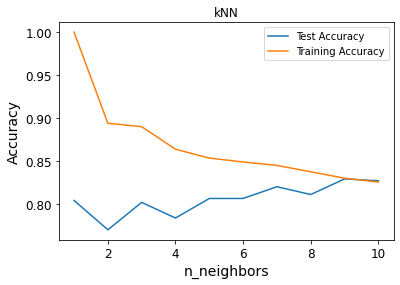

In [82]:
# n_neighbors from 1 to 10
knn = KNeighborsClassifier(n_neighbors=1)
knn = KNeighborsClassifier(n_neighbors=2)
knn = KNeighborsClassifier(n_neighbors=3)
knn = KNeighborsClassifier(n_neighbors=4)
knn = KNeighborsClassifier(n_neighbors=5)
knn = KNeighborsClassifier(n_neighbors=6)
knn = KNeighborsClassifier(n_neighbors=7)
knn = KNeighborsClassifier(n_neighbors=8)
knn = KNeighborsClassifier(n_neighbors=9)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)

print("Preliminary model score:")
print(knn.score(X_train,y_train))

no_neighbors = np.arange(1, 11)
train_accuracy = np.empty(len(no_neighbors))
test_accuracy = np.empty(len(no_neighbors))

for i, k in enumerate(no_neighbors):
    # build the model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)  
    # record training set accuracy
    train_accuracy[i] = knn.score(X_train, y_train)
    # record test set accuracy
    test_accuracy[i] = knn.score(X_test, y_test)

plt.title('kNN')
plt.plot(no_neighbors, test_accuracy, label = 'Test Accuracy')
plt.plot(no_neighbors, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.show()

80.36529680365297
76.9406392694064
80.13698630136986
78.31050228310502
80.59360730593608
80.59360730593608
81.9634703196347
81.05022831050228
82.87671232876713
82.64840182648402


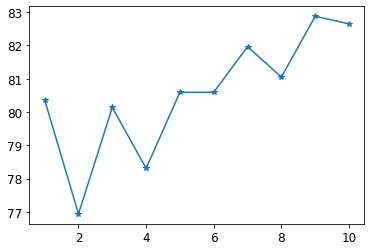

In [83]:
k_values = np.arange(1, 11, 1) 
results_acc = []

for k in k_values:
    knn_clf = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train) 
    y_pred1 = knn_clf.predict(X_test)
    # calculate accuracy
    acc = accuracy_score(y_test, y_pred1)*100
    print(acc)
    results_acc.append(acc)

plt.figure
plt.plot(k_values, results_acc, '-*') 
plt.show()

Above shows the accuracy score of using 1-10 k-values. We chose k = 9 because it gives the highest accuracy score at 82.815.

In [84]:
#predict using n_neighbors = 9
knn_clf = KNeighborsClassifier(n_neighbors=9).fit(X_train, y_train) 
ypred2 = knn_clf.predict(X_test)

Now that we know the accuracy of the model at k=9, let's check for the optimal k value to improve the model.


Minimum error:- 0.17123287671232876 at K = 8


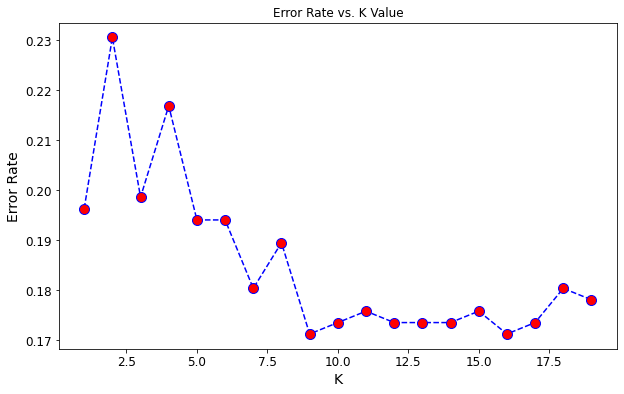

In [85]:
#Minimum error rate

error_rate = []
for i in range(1,20):
 knn = KNeighborsClassifier(n_neighbors=i)
 knn.fit(X_train,y_train)
 pred_i = knn.predict(X_test)
 error_rate.append(np.mean(pred_i != y_test))
plt.figure(figsize=(10,6))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

In the plot above, we can see that the minimum error is for k-value of 8 at -0.172. This is also known as the "elbow point." After k=8, the error rate becomes almost constant. This shows us that we will get better efficiency by using k=8. 

Let us know we visualise the plot between the error rate and accuracy rate. 

Maximum accuracy:- 0.8287671232876712 at K = 8


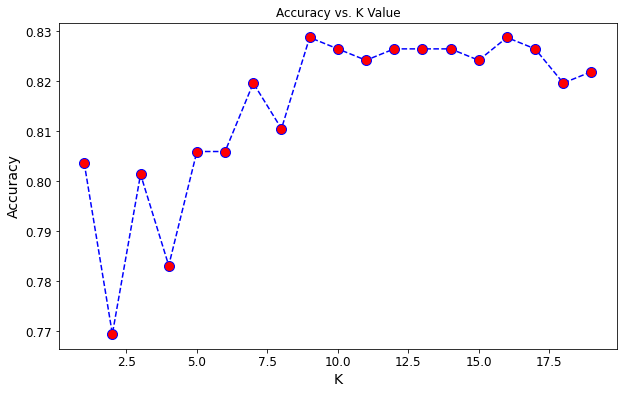

In [87]:
acc_score = []
for i in range(1,20):
    neigh = KNeighborsClassifier(n_neighbors = i).fit(X_train,y_train)
    yhat = neigh.predict(X_test)
    acc_score.append(metrics.accuracy_score(y_test, yhat))
    
plt.figure(figsize=(10,6))
plt.plot(range(1,20),acc_score,color = 'blue',linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
print("Maximum accuracy:-",max(acc_score),"at K =",acc_score.index(max(acc_score)))

We can see though that similar to our predicted model earlier, the accuracy score in using k=8 is 82.82. The accuracy score that we got is the same even if we choose k = 8 or k = 9. 

For this last question, we used kNN to predict the model. Using kNN is much simpler as compared to other more advanced machine learning techniques. As compared to SVM, kNN is much faster to do. In SVM, exploring using kernels and other parameters should be done to produce the best model however in kNN, after knowing the highest number of neighbors, you can easily predict the outcome already. kNN also shows that although the approach is much straightforward, it still give high accuracy predictions.


# Neural Network

In [185]:
# columns not to transform
not_cols =[
       'latest_year_enrolment_FTE', 'Indigenous_pct', 'LBOTE_pct',
       'ICSEA_value', 'Latitude', 'Longitude','final_ICSEA'
        ] 

# get dummies
df_dummies = pd.get_dummies(data=school_final, columns=[col for col in school_final.columns if col not in not_cols],drop_first=True)

In [186]:
data=df_dummies
data.head()

,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,ICSEA_value,final_ICSEA,Town_suburb_ADELONG,Town_suburb_ALLAMBIE HEIGHTS,Town_suburb_APPIN,Town_suburb_ARCADIA,Town_suburb_ARGENTON,...,SA4_Sydney - North Sydney and Hornsby,SA4_Sydney - Northern Beaches,SA4_Sydney - Outer South West,SA4_Sydney - Outer West and Blue Mountains,SA4_Sydney - Parramatta,SA4_Sydney - Ryde,SA4_Sydney - South West,SA4_Sydney - Sutherland,Healthy canteen_Y,final_Remotness_Sydney
0,309.0,14.000000,2.0,954.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,94.0,14.264935,15.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162.0,27.000000,5.0,891.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,51.0,16.000000,0.0,985.0,Medium,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.0,100.000000,15.0,653.0,Low,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [187]:
data.loc[(data.ICSEA_value <= 799) , 'final_ICSEA'] = 0
data.loc[(data.ICSEA_value >= 800) & (data.ICSEA_value <= 1000), 'final_ICSEA'] = 1
data.loc[(data.ICSEA_value >= 1001) , 'final_ICSEA'] = 2

In [188]:
data.head()

,latest_year_enrolment_FTE,Indigenous_pct,LBOTE_pct,ICSEA_value,final_ICSEA,Town_suburb_ADELONG,Town_suburb_ALLAMBIE HEIGHTS,Town_suburb_APPIN,Town_suburb_ARCADIA,Town_suburb_ARGENTON,...,SA4_Sydney - North Sydney and Hornsby,SA4_Sydney - Northern Beaches,SA4_Sydney - Outer South West,SA4_Sydney - Outer West and Blue Mountains,SA4_Sydney - Parramatta,SA4_Sydney - Ryde,SA4_Sydney - South West,SA4_Sydney - Sutherland,Healthy canteen_Y,final_Remotness_Sydney
0,309.0,14.000000,2.0,954.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,94.0,14.264935,15.0,985.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162.0,27.000000,5.0,891.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,51.0,16.000000,0.0,985.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.0,100.000000,15.0,653.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [189]:
# to assign X,Y values
y=df_dummies['final_ICSEA']
X=df_dummies.drop(['final_ICSEA','ICSEA_value'],axis=1)

#to split data as train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.05)


In [190]:
# to pre-process dataset to scaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
# to convert dataset X values to np array values as pre-processing and Y values as categorical
x_train = np.array(X_train)
x_test = np.array(X_test)
y_train1 = np.array(Y_train)
y_test1 = np.array(Y_test)
y_train= to_categorical(y_train1)
y_test= to_categorical(y_test1)


print(x_train.shape)
print(x_test.shape)
print(y_test.shape)


(2077, 1721)
(110, 1721)
(110, 3)


Dataset is split into train data and test data. Test data considered for validation is 5%. Neural Network model is created with three Dense Layers. The first Dense layer is given an input filter 16, with input dimension 1721 and activation Rectified Linear Unit 'relu'. The second Dense layer is added with filter 16 and activation 'relu'. The third Dense layer is given activation function 'sigmoid' and number of classes is 3. The model is trained with 8 epochs, batch size 10. The epochs is the number of iterations used for learning. The batch size used is 10 instance taken for learning each time. The model is varied with batch size, number of epochs and test set size manually to get better accuracy and the better parameter is used to fit the model.
 

In [191]:
# to build neural network model
#create an instance of deep learning model 
model = Sequential()
#add a dense layer with filter 16 and input dimension 1721
model.add(Dense(16, activation='relu', input_dim=1721))
#add a dense layer with filter 16 and activation relu
model.add(Dense(16, activation='relu'))
#Output layer, a dense layer with 3 classes as output and activation function 'softmax'
model.add(Dense(3, activation='softmax'))
#compile the model
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
#fit model with train and validation data with batch size and epochs
history=model.fit(x_train, y_train, batch_size=10, epochs=8, validation_data=(x_test, y_test))
#evaluate model with loss and accuracy
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)
# to save model history for plotting
history_dict = history.history
print(history_dict.keys())

Epoch 1/8
208/208 [==============================] - 2s 5ms/step - loss: 0.7353 - accuracy: 0.6697 - val_loss: 0.5293 - val_accuracy: 0.7545
Epoch 2/8
208/208 [==============================] - 1s 4ms/step - loss: 0.5164 - accuracy: 0.7790 - val_loss: 0.4667 - val_accuracy: 0.7909
Epoch 3/8
208/208 [==============================] - 1s 4ms/step - loss: 0.4386 - accuracy: 0.8252 - val_loss: 0.4473 - val_accuracy: 0.8364
Epoch 4/8
208/208 [==============================] - 1s 4ms/step - loss: 0.3642 - accuracy: 0.8710 - val_loss: 0.4485 - val_accuracy: 0.8091
Epoch 5/8
208/208 [==============================] - 1s 4ms/step - loss: 0.2894 - accuracy: 0.8994 - val_loss: 0.4105 - val_accuracy: 0.8182
Epoch 6/8
208/208 [==============================] - 1s 4ms/step - loss: 0.2186 - accuracy: 0.9263 - val_loss: 0.3886 - val_accuracy: 0.8455
Epoch 7/8
208/208 [==============================] - 1s 4ms/step - loss: 0.1588 - accuracy: 0.9514 - val_loss: 0.4196 - val_accuracy: 0.8364
Epoch 8/8
4/4

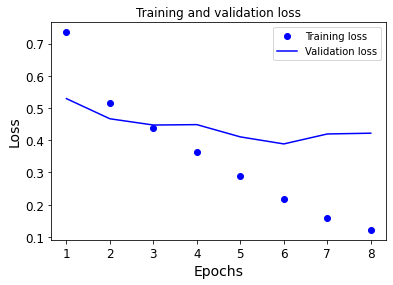

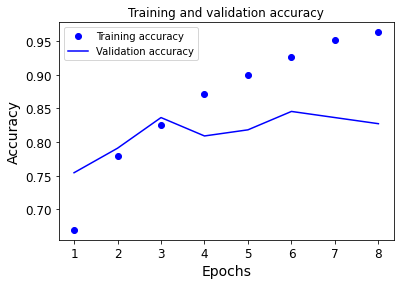

<Figure size 432x288 with 0 Axes>

In [192]:
# get accuracy and loss metrics from compiled model for training data and validation data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# to plot loss metrics for training and validation 	
#assign epoch range for x-axis
epochs = range(1, len(acc) + 1)
# plot for epochs vs training loss
plt.plot(epochs, loss, 'bo', label='Training loss')
# plot for epochs vs training loss
plt.plot(epochs, val_loss, 'b', label='Validation loss')
#plot title, and X,Y axis labels
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
#plt.savefig('charts/NN_loss.png') 
plt.show(block=True)
plt.close()	
plt.clf()   

# to plot accuracy metrics for training and validation 	
# get accuracy metrics from compiled model for training data and validation data
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
# plot for epochs vs training accuracy
plt.plot(epochs, acc, 'bo', label='Training accuracy')
# plot for epochs vs validation accuracy
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
#plot title, and X,Y axis labels
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
#plt.savefig('charts/NNAccuracy.png') 
plt.show(block=True)
plt.close()
plt.clf()  



MLP model has achieved high accuracy than Neural Network model. MLP is considered good model than neural network model. Training as well as validation accuracy is high for MLP classifier.
 

For Multilayer Perceptron (MLP) classifier, activation used is Rectified Linear Unit 'relu', solver used is Stochastic Gradient Descent (SGD), for bias and weight computation random_state used is 3, hidden layer size used is (15,15) and maximum iteration is 10000. This model is fit with train data. The model is validated for train and test accuracy metrics.

In [193]:
#import MLP classifier from sklean package
from sklearn.neural_network import MLPClassifier
#create MLPclassifier with activation function'relu', hiddenn layer size (15,15)
nn = MLPClassifier(activation = 'relu', solver = 'sgd', hidden_layer_sizes = (15, 15), random_state=3, max_iter=10000, 
                   alpha = 1)
#fit train data to the classifier
nn.fit(x_train, y_train)

MLPClassifier(alpha=1, hidden_layer_sizes=(15, 15), max_iter=10000,
              random_state=3, solver='sgd')

In [194]:
#predict using test data
pred = nn.predict(x_test)
#predict using train data
pred_traindata = nn.predict(x_train)
from sklearn.metrics import accuracy_score
#compute accuracy for test data
print(accuracy_score(y_test, pred))
#compute accuracy for train data
print(accuracy_score(y_train, pred_traindata))

0.8545454545454545
0.9682233991333654


The accuracy of Neural Network model is 82.3%. This model has achieved training accuracy of around 96.3% and validation accuracy around 82.3%.
The accuracy of Multi layer perceptron (MLP) model is 85.45% for test data and 96.8% for training data.
The MLP classifier has achieved highest accuracy of 85.45%.
 

# Comparison of all the models

In [13]:
data = [["a.Linear SVM using all variables", 84.5], 
        ["b.SVM using kernel rbf using all variables", 83.7], 
        ["c.SVM by tuning parameter using all variables", 85.6], 
        ["d.Variable selection using Lasso and then SVM with selected variables", 83.7],
        ["e.Variable selection using PCA and then SVM with selected variables", 45.8],
        ["f.KNN", 82.8],
        ["g.Neural Network using dense layers", 82.7],
        ["h.Neural Network using MLP ", 85.5]
        
       ]
  
#define header names
col_names = ["Method", "Accuracy %"]
  
#display table
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒═══════════════════════════════════════════════════════════════════════╤══════════════╕
│ Method                                                                │   Accuracy % │
╞═══════════════════════════════════════════════════════════════════════╪══════════════╡
│ a.Linear SVM using all variables                                      │         84.5 │
├───────────────────────────────────────────────────────────────────────┼──────────────┤
│ b.SVM using kernel rbf using all variables                            │         83.7 │
├───────────────────────────────────────────────────────────────────────┼──────────────┤
│ c.SVM by tuning parameter using all variables                         │         85.6 │
├───────────────────────────────────────────────────────────────────────┼──────────────┤
│ d.Variable selection using Lasso and then SVM with selected variables │         83.7 │
├───────────────────────────────────────────────────────────────────────┼──────────────┤
│ e.Variable selectio

The accuracy of the model using MLP is 85.5% and using SVM with linear kernel is 85.6% after parameter tuning. KNN also has a comparable accuracy at 82.8% and has the fastest run time compared to all the above methods.
 Neural Networks are able to generalize the data better and are consistenly resistant to noise. The loss of the data in this model is minimal. 
- SVM and KNN algorithms showed that both classifiers mapped the classes High, medium and Low with similar accuracy, SVM outperformed in terms of precision rate with average accuracy of 85% after tuning the optimal parameters.

In order to achieve better prediction accuracy, variable selection is performed using Lasso and PCA to retain only the important information.
- The accuracy of the model after variable selection using lasso does not show any major improvement in terms of accuracy. However, the run time for the model has improved compared to the previous svm model using all variables.Same with the Recall measure, The model with less variables has a higher recall, it means that identify correctly between the three classes (High, Medium, Low) than the other models. 

- The accuracy, precision and recall  of the model using PCA is drastically low compared to the previous ones. We can conclude that using PCA is not improving the classification accuracy. Every component is a linear combination of x variables and its not necessary that the combination chosen contains the features which will improve the accuracy of the SVM model. 